# 03 — 2D Baseline Analysis (Phase 4)

## Objective
Establish the reference result for all later comparisons: a single-slice (2D) CNN that scores LUNA16 candidates (objectness + box), evaluated with the official FROC/CPM protocol. **EXP-001-baseline-2d**, one seed (42), checkpoint chosen on validation CPM only; the test split was scored once.

## Configuration

In [1]:
from pathlib import Path
EXP = Path('../experiments/baseline/EXP-001-baseline-2d')
FIG = Path('../results/figures')

## Imports

In [2]:
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
import yaml
cfg = yaml.safe_load((EXP/'config.yaml').read_text())
m = json.loads((EXP/'metrics.json').read_text()); h = pd.read_csv(EXP/'history.csv')

## Setup

In [3]:
print({k: cfg[k] for k in ['data', 'model', 'training', 'loss']})
print('parameters:', m['efficiency']['parameters'], '| size MB:', round(m['efficiency']['model_size_mb'], 2))

{'data': {'input_slices': 5, 'slice_stride': 1, 'patch_size': 64, 'cache_dir': 'data/processed', 'channels': [2], 'pos_repeat': 10, 'augment': 'dihedral'}, 'model': {'attention': False, 'backbone': 'simple_cnn', 'in_channels': 1, 'widths': [16, 32, 64, 128], 'head_hidden': 64, 'dropout': 0.2}, 'training': {'batch_size': 256, 'epochs': 20, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'scheduler': 'cosine', 'selection_metric': 'val_cpm'}, 'loss': {'lambda_cls': 1.0, 'lambda_loc': 1.0, 'focal_alpha': 0.25, 'focal_gamma': 2.0}}
parameters: 302228 | size MB: 1.21


## Training curves
Training loss is `L_total = L_det = λ_cls·L_focal + λ_loc·L_loc` (both λ = 1). Validation CPM is noisy epoch to epoch (118 validation nodules: one nodule ≈ 0.85 % sensitivity), so the best epoch is a noisy pick.

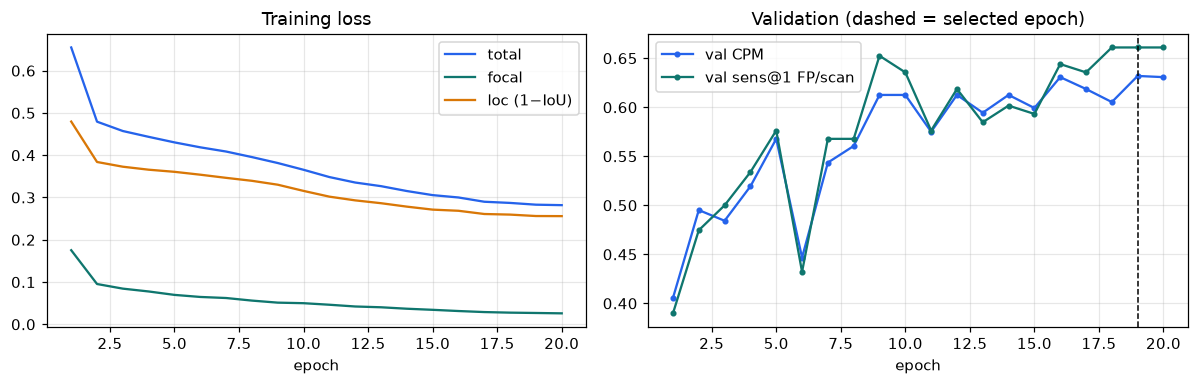

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(h.epoch, h.train_loss, label='total', color='#2563EB'); ax[0].plot(h.epoch, h.train_focal, label='focal', color='#0F766E'); ax[0].plot(h.epoch, h.train_loc, label='loc (1−IoU)', color='#D97706'); ax[0].set(xlabel='epoch', title='Training loss'); ax[0].legend()
ax[1].plot(h.epoch, h.val_cpm, color='#2563EB', marker='o', ms=3, label='val CPM'); ax[1].plot(h.epoch, h['val_sens@1'], color='#0F766E', marker='o', ms=3, label='val sens@1 FP/scan')
ax[1].axvline(m['epoch'], color='k', ls='--', lw=1); ax[1].set(xlabel='epoch', title='Validation (dashed = selected epoch)'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'EXP-001-baseline-2d_training.png'); plt.show()

## Detection performance (official LUNA16 protocol)

In [5]:
rows = []
for s in ['val', 'test']:
    d = m[s]; rows.append({'split': s, 'scans': d['n_scans'], 'nodules': d['n_nodules'], 'CPM': d['cpm'], **{f'sens@{r}': d[f'sens@{r}'] for r in [0.125, 0.25, 0.5, 1, 2, 4, 8]}, 'max sens': d['max_sensitivity'], 'random-score CPM': d['random_scores_cpm_reference']})
pd.DataFrame(rows).round(3)

,split,scans,nodules,CPM,sens@0.125,sens@0.25,sens@0.5,sens@1,sens@2,sens@4,sens@8,max sens,random-score CPM
0,val,88,118,0.632,0.381,0.508,0.576,0.661,0.703,0.763,0.831,0.958,0.007
1,test,88,105,0.675,0.400,0.476,0.648,0.695,0.771,0.857,0.876,0.962,0.005


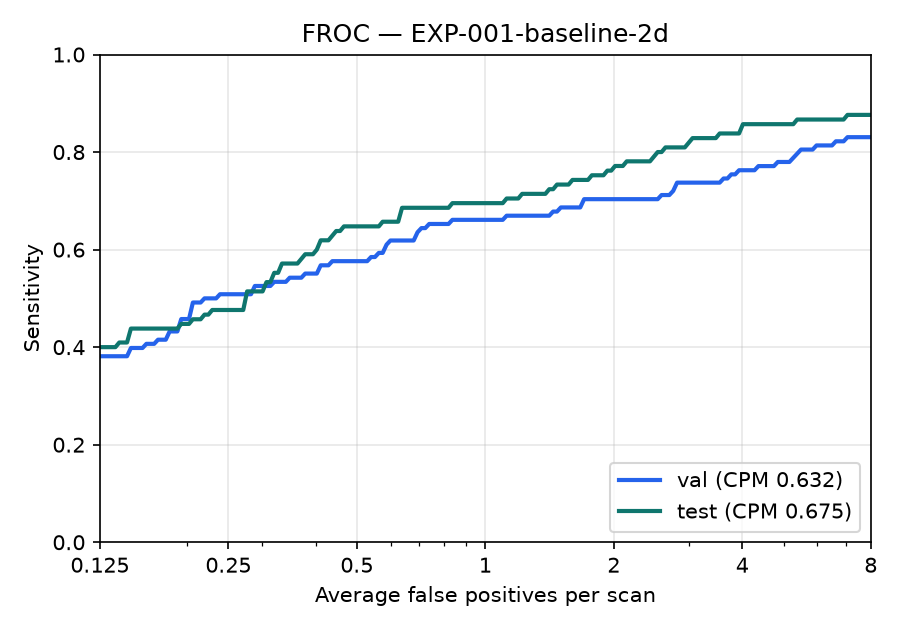

In [6]:
from IPython.display import Image; Image(str(FIG/'EXP-001-baseline-2d_froc.png'))

`max sens` is the ceiling set by the candidate list (and the official cap of 100 marks per scan): nodules without a candidate can never be detected. The random-score row is the floor (≈ 0.005).

## Efficiency (measured, documented conditions)

In [7]:
e = m['efficiency']
rows = [{'measure': 'parameters', 'value': e['parameters']}, {'measure': 'model size (MB, fp32)', 'value': round(e['model_size_mb'], 3)}, {'measure': 'sparsity', 'value': round(e['sparsity'], 5)}]
for k in [k for k in e if k.startswith('latency')]:
    rows.append({'measure': f"{k}: {e[k]['latency_ms_mean']:.2f} ± {e[k]['latency_ms_std']:.2f} ms (warm-up {e[k]['warmup']}, {e[k]['runs']} runs)", 'value': f"{e[k]['throughput_samples_per_s']:.0f} samples/s"})
pd.DataFrame(rows)

,measure,value
0,parameters,302228
1,"model size (MB, fp32)",1.209
2,sparsity,0.00009
3,latency_cpu_batch1: 1.56 ± 0.44 ms (warm-up 10...,640 samples/s
4,latency_cpu_batch256: 166.16 ± 14.93 ms (warm-...,1541 samples/s
5,latency_mps_batch256: 24.48 ± 0.73 ms (warm-up...,10458 samples/s


## Caveats and conclusions
* One training run (single seed), small validation/test sets (118 / 105 nodules): differences of a few CPM points between runs are within noise. A bootstrap confidence interval should be added before drawing conclusions from small differences.
* Test CPM (0.675) being above validation CPM (0.632) is consistent with split noise, not evidence of anything.
* This is a **candidate-scoring** baseline on the supplied LUNA16 candidates (`candidates_V2`), the standard false-positive-reduction setting of the official protocol, not a full-scan detector. FROC/CPM are the official ones (validated against the bundled example output).
* FLOPs/MACs are not yet measured (Phase 6/13).

Phase 4 gate: the 2D baseline runs end to end (dataset → training → checkpoint → prediction → evaluation).

---
# Phase 6 — 2.5D CNN baseline: 1 vs 3 vs 5 input slices

Identical model, loss, optimiser, 20 epochs, splits and checkpoint rule (best validation CPM); only the number of centre-aligned input slices changes (1 / 3 / 5, 1 mm apart). 1 and 5 slices: 3 seeds each (42–44; EXP-001 is the 1-slice seed-42 run); 3 slices: seed 42 only. Produced by `scripts/run_sweep.py` + `scripts/compare_experiments.py`. Decisions use the **validation** split.

In [8]:
import json
import pandas as pd
from IPython.display import Image, display
T = '../results/tables'; F = '../results/figures'
pd.read_csv(f'{T}/phase6_runs.csv').round(4)

,experiment,slices,seed,epoch,val_cpm,test_cpm,val_sens@1,test_sens@1,val_max_sens,params,MFLOPs,cpu_ms_b1
0,EXP-001-baseline-2d,1,42,19,0.6320,0.6748,0.6610,0.6952,0.9576,302228,105.0056,1.5634
1,EXP-002-slices1-s43,1,43,16,0.6186,0.6871,0.6525,0.6952,0.9322,302228,105.0056,2.4207
2,EXP-002-slices1-s44,1,44,13,0.6077,0.6408,0.6356,0.6667,0.9322,302228,105.0056,1.3886
3,EXP-002-slices3-s42,3,42,16,0.7070,0.8000,0.7458,0.8667,0.9576,302516,107.3649,4.0141
4,EXP-002-slices5-s42,5,42,16,0.7881,0.8544,0.8051,0.9238,0.9661,302804,109.7242,2.1219
5,EXP-002-slices5-s43,5,43,13,0.8208,0.8789,0.8644,0.9048,0.9661,302804,109.7242,2.1226
6,EXP-002-slices5-s44,5,44,15,0.7869,0.8748,0.8136,0.9048,0.9746,302804,109.7242,2.2980


## By slice count (mean ± std over seeds)

In [9]:
pd.read_csv(f'{T}/phase6_by_slices.csv').round(4)

,slices,runs,val_cpm_mean,val_cpm_std,test_cpm_mean,test_cpm_std,val_sens1_mean,test_sens1_mean,params,MFLOPs,cpu_ms_b1
0,1,3,0.6195,0.0121,0.6676,0.0240,0.6497,0.6857,302228,105.0056,1.7909
1,3,1,0.7070,NaN,0.8000,NaN,0.7458,0.8667,302516,107.3649,4.0141
2,5,3,0.7986,0.0192,0.8694,0.0131,0.8277,0.9111,302804,109.7242,2.1808


## Evaluation-set uncertainty: paired scan-level bootstrap (1000 resamples, same resamples for all models)

In [10]:
o = json.load(open(f'{T}/phase6_comparison.json'))
rows = []
for split in ('val', 'test'):
    for k, v in o['bootstrap'][split].items():
        rows.append({'split': split, 'quantity': k, 'value': v.get('cpm_mean', v.get('delta_cpm')), 'ci95_low': v['ci95'][0], 'ci95_high': v['ci95'][1]})
pd.DataFrame(rows).round(3)

,split,quantity,value,ci95_low,ci95_high
0,val,1-slice,0.618,0.540,0.698
1,val,3-slice,0.708,0.624,0.792
2,val,5-slice,0.797,0.721,0.863
3,val,3-slice minus 1-slice,0.090,0.034,0.152
4,val,5-slice minus 1-slice,0.179,0.117,0.244
5,val,5-slice minus 3-slice,0.089,0.045,0.130
6,test,1-slice,0.664,0.591,0.733
7,test,3-slice,0.804,0.738,0.867
8,test,5-slice,0.868,0.818,0.918
9,test,3-slice minus 1-slice,0.140,0.076,0.208


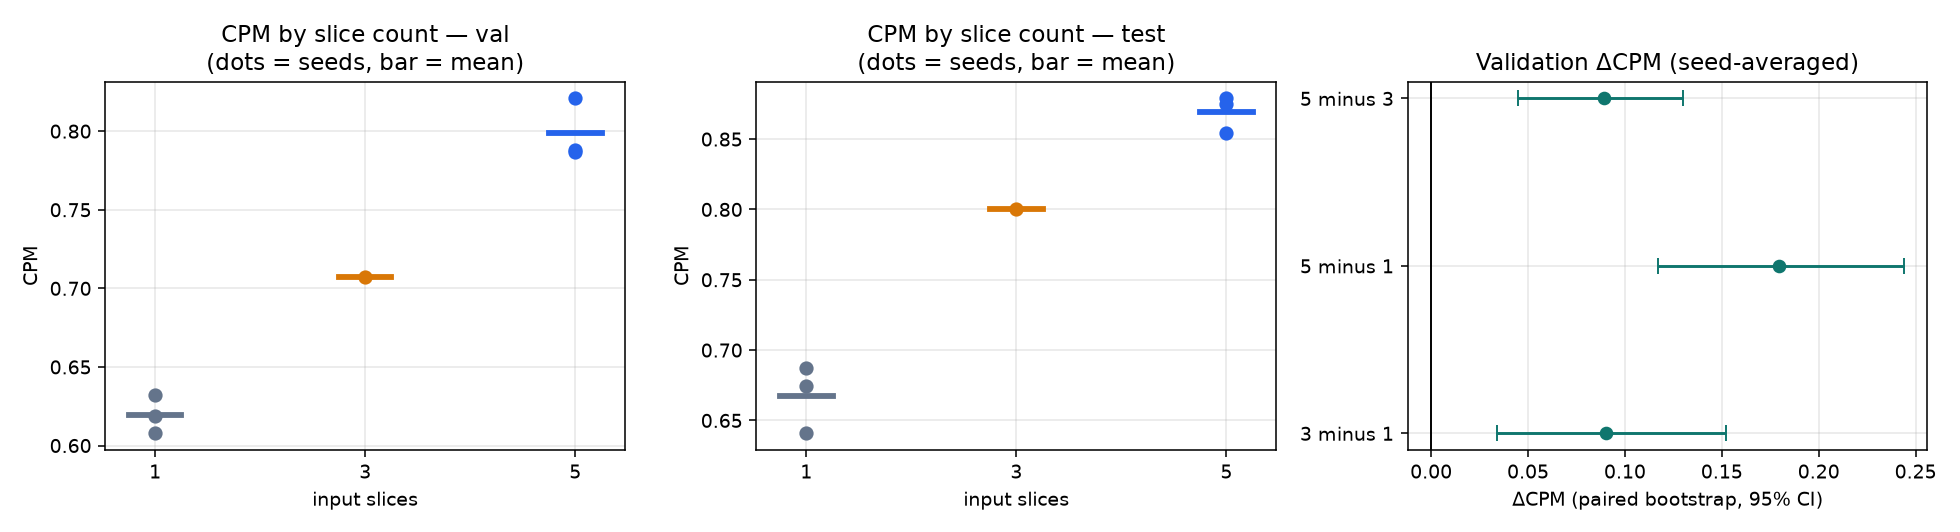

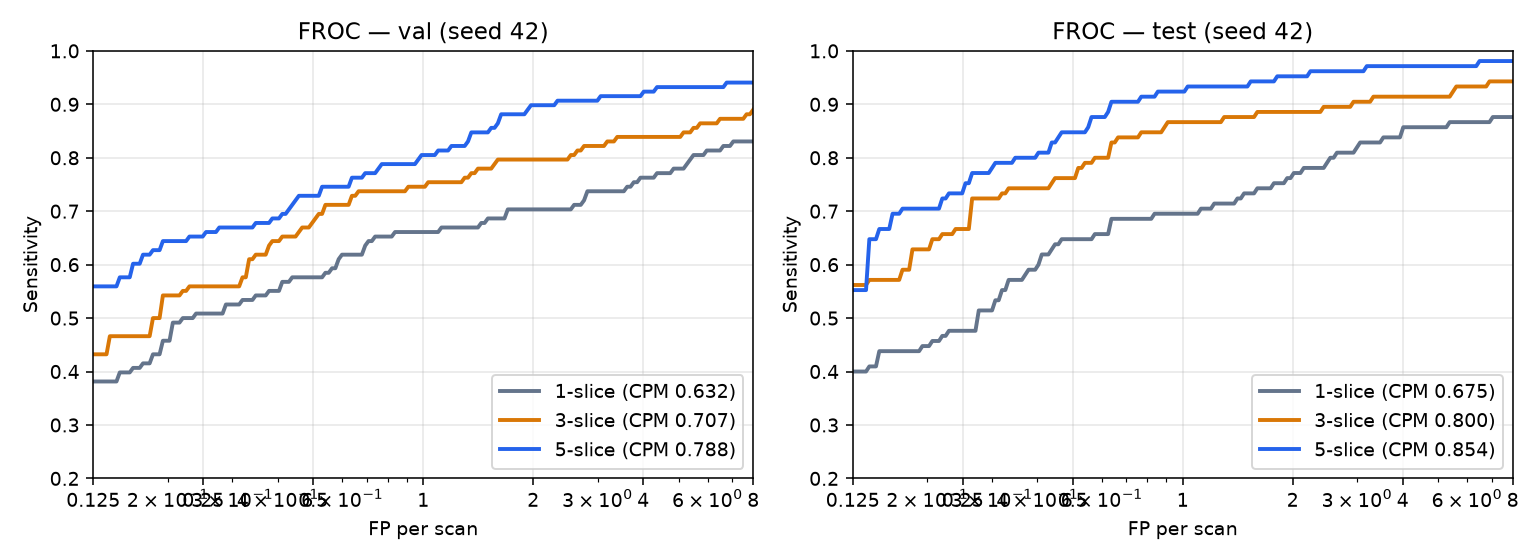

In [11]:
display(Image(f'{F}/phase6_cpm_comparison.png')); display(Image(f'{F}/phase6_froc.png'))

## Sensitivity by nodule size at 1 FP/scan (mean over seeds)

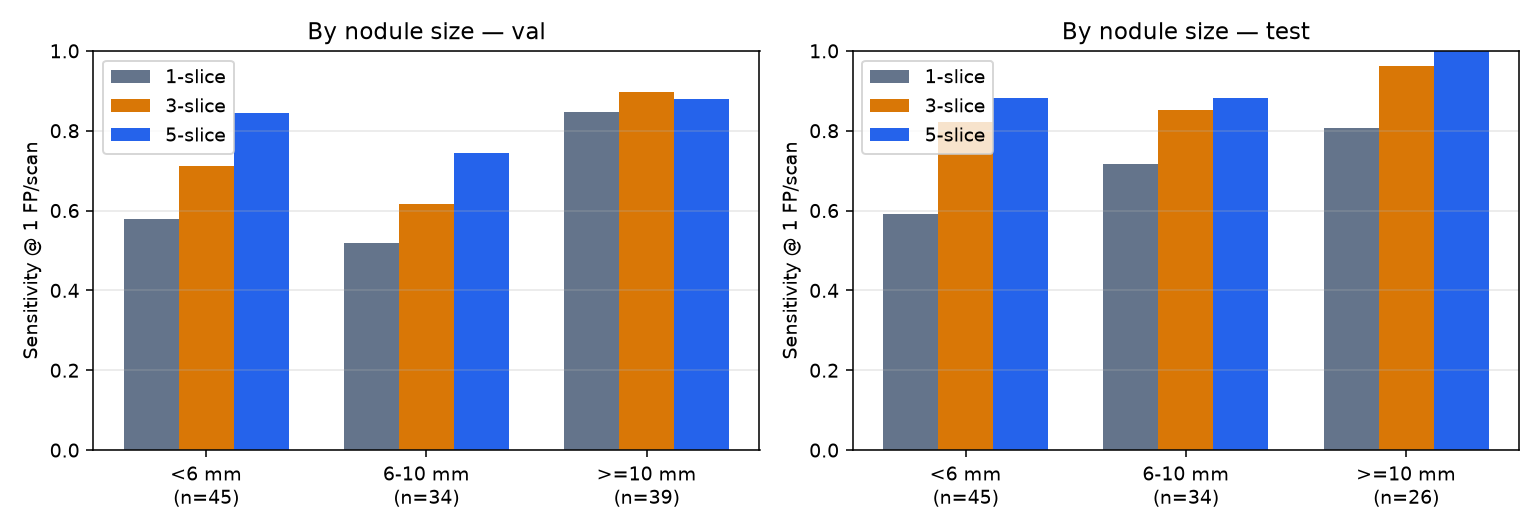

model          1-slice  3-slice  5-slice
split size                              
test  6-10 mm    0.716    0.853    0.882
      <6 mm      0.593    0.822    0.881
      >=10 mm    0.808    0.962    1.000
val   6-10 mm    0.520    0.618    0.745
      <6 mm      0.578    0.711    0.844
      >=10 mm    0.846    0.897    0.880

In [12]:
display(Image(f'{F}/phase6_by_size.png'))
rows = [{'split': s, 'model': m, 'size': b, 'nodules': d['nodules'], 'sensitivity': round(d['sensitivity'], 3)} for s, ms in o['by_size_at_1fp'].items() for m, bs in ms.items() for b, d in bs.items()]
pd.DataFrame(rows).pivot_table(index=['split', 'size'], columns='model', values='sensitivity')

## Findings
* More slices help substantially: validation CPM 0.620 ± 0.012 (1 slice) → 0.707 (3 slices, 1 seed) → 0.799 ± 0.019 (5 slices). Every 5-slice seed beats every 1-slice seed; paired bootstrap ΔCPM(5−1) = +0.18 (95% CI +0.12 … +0.24); the test split agrees (+0.20).
* The gain is concentrated in **small and medium nodules** (val sensitivity @1 FP/scan: <6 mm 0.58 → 0.84; 6–10 mm 0.52 → 0.75; ≥10 mm 0.85 → 0.88), consistent with the Phase 5 input statistics (small-nodule cores fade by ±2 mm).
* Cost is negligible: +576 parameters (+0.2%) and +4.5% FLOPs (105.0 → 109.7 MFLOPs/sample); only the first convolution grows. Batch-1 CPU latencies in the table are noisy (machine was in use; e.g. the 3-slice outlier) and should not be compared.
* Caveats: 3-slice has one seed; effects are measured with one architecture and one patch size; the monotone 1 < 3 < 5 trend suggests even wider context (7 slices or larger stride) may help — untested (needs a new patch cache).

**Gate 2:** the 2.5D representation is technically viable and clearly better than 2D → continue; the 5-slice input is the default for Phase 7.